# Hybrid Risk Score (HRS) Calculation — Isha Role

This notebook computes the Hybrid Risk Score (HRS) by combining:

• Logistic Regression feature weights  
• SHAP feature importance (CatBoost)  
• Domain priority weights  

The HRS equation is:

HRS = α·LR_weight + β·SHAP_weight + γ·Domain_priority

The score will be used to classify patients into risk categories.

In [1]:
import pandas as pd
import numpy as np

## Create Domain Priority Weights Table

This table assigns domain knowledge weights to each clinical feature.
These weights reflect the relative medical importance of each variable
in predicting heart disease risk.

The table will be saved as:

domain_priority.csv

In [2]:
import pandas as pd

domain_df = pd.DataFrame({
    "feature": [
        "age", "sex_Male",
        "cp_atypical angina", "cp_non-anginal", "cp_typical angina",
        "trestbps", "chol", "fbs_True", "restecg_normal", "restecg_st-t abnormality",
        "thalch", "exang_True", "oldpeak", "slope_flat", "slope_upsloping",
        "ca", "thal_normal", "thal_reversable defect"
    ],
    "domain_priority": [
        0.80, 0.40,
        1.00, 1.00, 1.00,
        0.85, 0.75, 0.50, 0.60, 0.60,
        0.80, 0.95, 0.95, 0.90, 0.90,
        0.95, 0.90, 0.90
    ]
})

domain_df.to_csv("domain_priority.csv", index=False)
print("Domain priority table created and saved.")
domain_df

Domain priority table created and saved.


,feature,domain_priority
0,age,0.80
1,sex_Male,0.40
2,cp_atypical angina,1.00
3,cp_non-anginal,1.00
4,cp_typical angina,1.00
5,trestbps,0.85
6,chol,0.75
7,fbs_True,0.50
8,restecg_normal,0.60
9,restecg_st-t abnormality,0.60


## Load Feature Importance Inputs

In [3]:
# Logistic Regression coefficients
lr_df = pd.read_csv("/content/T3_lr_coefficients.csv")

# SHAP importance (from CatBoost model)
shap_df = pd.read_csv("/content/catboost_shap_importance.csv")

# Domain priority weights
domain_df = pd.read_csv("/content/domain_priority.csv")

In [4]:
print("LR table")
display(lr_df.head())

print("SHAP table")
display(shap_df.head())

print("Domain priority table")
display(domain_df.head())

LR table


,Feature,Coefficient,Normalized Weight
0,age,0.117132,0.020782
1,trestbps,0.087135,0.015460
2,chol,-0.451543,0.080113
3,thalch,-0.210691,0.037381
4,oldpeak,0.499984,0.088708


SHAP table


,feature,shap_importance,rank
0,oldpeak,0.528868,1
1,cp_atypical angina,0.492734,2
2,sex_Male,0.400086,3
3,chol,0.350766,4
4,exang_True,0.346677,5


Domain priority table


,feature,domain_priority
0,age,0.8
1,sex_Male,0.4
2,cp_atypical angina,1.0
3,cp_non-anginal,1.0
4,cp_typical angina,1.0


# Normalize LR Coefficients

In [5]:
lr_df['signed_normalized_weight'] = (
    lr_df['Coefficient'] / abs(lr_df['Coefficient']).sum()
)

## Normalize SHAP Feature Importance

SHAP importance values are normalized to the range [0,1] to ensure
they are comparable with Logistic Regression weights.

In [6]:
shap_df["shap_importance"] = (
    (shap_df["shap_importance"] - shap_df["shap_importance"].min()) /
    (shap_df["shap_importance"].max() - shap_df["shap_importance"].min())
)

## Normalize Domain Priority

Domain Priority values are normalized to the range [0,1] to ensure
they are comparable with Logistic Regression weights.

In [7]:
domain_df["domain_priority"] = (
    (domain_df["domain_priority"] - domain_df["domain_priority"].min()) /
    (domain_df["domain_priority"].max() - domain_df["domain_priority"].min())
)

domain_df.head()

,feature,domain_priority
0,age,0.666667
1,sex_Male,0.000000
2,cp_atypical angina,1.000000
3,cp_non-anginal,1.000000
4,cp_typical angina,1.000000


## Extract Logistic Regression Feature Weights

The Logistic Regression output already contains normalized feature weights.
We use the "Normalized Weight" column as the LR importance score.

In [8]:
# Keep only required columns
lr_df = lr_df[["Feature", "signed_normalized_weight"]]

# Rename columns to match the pipeline
lr_df = lr_df.rename(columns={
    "Feature": "feature",
    "Normalized Weight": "LR_weight"
})

lr_df.head()

,feature,signed_normalized_weight
0,age,0.020782
1,trestbps,0.015460
2,chol,-0.080113
3,thalch,-0.037381
4,oldpeak,0.088708


## Combine LR, SHAP and Domain Weights

This step merges the three feature importance sources:

• Logistic Regression weights  
• SHAP feature importance (CatBoost)  
• Domain priority weights  

The merged table will be used to compute the Hybrid Risk Score (HRS).

In [9]:
# Merge LR + SHAP
merged = pd.merge(
    lr_df,
    shap_df[["feature", "shap_importance"]],
    on="feature"
)

# Merge domain priority
merged = pd.merge(
    merged,
    domain_df,
    on="feature"
)

merged

,feature,signed_normalized_weight,shap_importance,domain_priority
0,age,0.020782,0.293072,0.666667
1,trestbps,0.015460,0.173396,0.750000
2,chol,-0.080113,0.656037,0.583333
3,thalch,-0.037381,0.431498,0.666667
4,oldpeak,0.088708,1.000000,0.916667
5,ca,0.112170,0.642164,0.916667
6,sex_Male,0.101802,0.751287,0.000000
7,cp_atypical angina,-0.136805,0.930214,1.000000
8,cp_non-anginal,-0.096636,0.565118,1.000000
9,cp_typical angina,-0.054537,0.128800,1.000000


## Compute Hybrid Risk Score Contribution

The Hybrid Risk Score (HRS) combines three importance sources:

HRS = α·LR_weight + β·SHAP_importance + γ·Domain_priority

In [28]:
alpha = 0.7
beta = 0.2
gamma = 0.1

merged["hrs_component"] = (
    alpha * merged["signed_normalized_weight"] +
    beta * merged["shap_importance"] +
    gamma * merged["domain_priority"]
)

merged

,feature,signed_normalized_weight,shap_importance,domain_priority,hrs_component
0,age,0.020782,0.293072,0.666667,0.139828
1,trestbps,0.015460,0.173396,0.750000,0.120501
2,chol,-0.080113,0.656037,0.583333,0.133461
3,thalch,-0.037381,0.431498,0.666667,0.126799
4,oldpeak,0.088708,1.000000,0.916667,0.353762
5,ca,0.112170,0.642164,0.916667,0.298618
6,sex_Male,0.101802,0.751287,0.000000,0.221519
7,cp_atypical angina,-0.136805,0.930214,1.000000,0.190279
8,cp_non-anginal,-0.096636,0.565118,1.000000,0.145379
9,cp_typical angina,-0.054537,0.128800,1.000000,0.087584


## Save HRS Feature Components

In [29]:
merged.to_csv("hrs_feature_components.csv", index=False)

print("HRS feature component table saved")

HRS feature component table saved


# Load Train Dataset to learn scaler

In [11]:
train_df = pd.read_csv("/content/train_raw.csv")

train_df.head()

,id,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,dataset_Hungary,dataset_Switzerland,...,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect,target
0,881,62,132.132404,170.000000,120.000000,3.000000,0.676375,True,False,False,...,False,False,False,True,True,False,False,False,False,1
1,458,54,150.000000,199.130337,122.000000,0.000000,0.676375,True,True,False,...,False,False,True,False,False,False,False,False,False,0
2,798,51,132.132404,339.000000,137.545665,0.878788,0.676375,True,False,False,...,False,False,True,False,False,False,False,False,False,1
3,26,50,120.000000,219.000000,158.000000,1.600000,0.000000,False,False,False,...,False,False,True,False,False,True,False,True,False,0
4,85,52,120.000000,325.000000,172.000000,0.200000,0.000000,True,False,False,...,False,False,True,False,False,False,True,True,False,0


## Load Test Dataset

The test dataset contains patient feature values.
These will be used together with the HRS feature contributions
to compute the final patient risk scores.

In [12]:
test_df = pd.read_csv("/content/test_raw.csv")

test_df.head()

,id,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,dataset_Hungary,dataset_Switzerland,...,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect,target
0,320,36,120.0,166.0,180.0,0.0,0.676375,True,True,False,...,False,False,True,False,False,False,False,False,False,0
1,378,45,140.0,224.0,122.0,0.0,0.676375,True,True,False,...,False,True,True,False,False,False,False,False,False,0
2,539,48,160.0,329.0,92.0,1.5,0.676375,True,True,False,...,False,False,True,False,True,True,False,False,False,1
3,297,59,164.0,176.0,90.0,1.0,2.000000,True,False,False,...,False,True,False,False,False,True,False,False,False,1
4,532,40,150.0,392.0,130.0,2.0,0.676375,False,True,False,...,False,False,True,False,False,True,False,False,False,1


## Compute Patient Hybrid Risk Score

Each patient's risk score is computed by multiplying their
feature values with the corresponding HRS feature contribution.

In [31]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score

# Extract feature contribution vector
hrs_weights = merged.set_index("feature")["hrs_component"]
hrs_features = hrs_weights.index.tolist()

# Fix booleans
test_df_fixed = test_df.replace({True: 1, False: 0})
train_df_fixed = train_df.replace({True: 1, False: 0})

# Minmax scale using train
scaler = MinMaxScaler()
scaler.fit(train_df_fixed[hrs_features])

X_test_scaled = pd.DataFrame(
    scaler.transform(test_df_fixed[hrs_features]),
    columns=hrs_features
)

# Compute HRS score
test_df_fixed["HRS_score"] = X_test_scaled.dot(hrs_weights)

# Check AUC
auc = roc_auc_score(test_df_fixed['target'], test_df_fixed['HRS_score'])
print(f"AUC: {auc:.3f}")

test_df_fixed.head()

AUC: 0.743


/tmp/ipykernel_7790/1853406975.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df_fixed = test_df.replace({True: 1, False: 0})
/tmp/ipykernel_7790/1853406975.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df_fixed = train_df.replace({True: 1, False: 0})


,id,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,dataset_Hungary,dataset_Switzerland,...,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect,target,HRS_score
0,320,36,120.0,166.0,180.0,0.0,0.676375,1,1,0,...,0,1,0,0,0,0,0,0,0,0.859979
1,378,45,140.0,224.0,122.0,0.0,0.676375,1,1,0,...,1,1,0,0,0,0,0,0,0,0.902884
2,539,48,160.0,329.0,92.0,1.5,0.676375,1,1,0,...,0,1,0,1,1,0,0,0,1,1.261309
3,297,59,164.0,176.0,90.0,1.0,2.000000,1,0,0,...,1,0,0,0,1,0,0,0,1,1.111694
4,532,40,150.0,392.0,130.0,2.0,0.676375,0,1,0,...,0,1,0,0,1,0,0,0,1,0.812678


Best threshold: 1.109
Accuracy: 0.717
              precision    recall  f1-score   support

           0       0.61      0.85      0.71        75
           1       0.86      0.62      0.72       109

    accuracy                           0.72       184
   macro avg       0.74      0.74      0.72       184
weighted avg       0.76      0.72      0.72       184



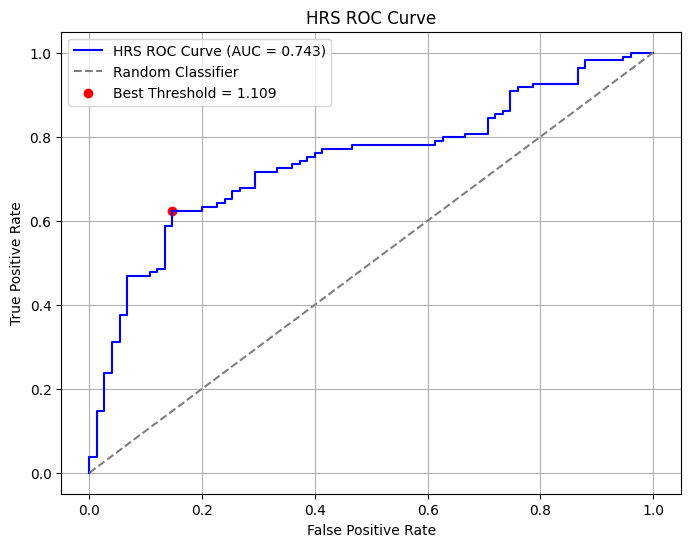

In [32]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(test_df_fixed['target'], test_df_fixed['HRS_score'])

# Best threshold
youden_j = tpr - fpr
best_idx = youden_j.argmax()
best_threshold = thresholds[best_idx]
print(f"Best threshold: {best_threshold:.3f}")

# Apply threshold
test_df_fixed['risk_class'] = (test_df_fixed['HRS_score'] >= best_threshold).astype(int)

# Accuracy
from sklearn.metrics import accuracy_score, classification_report
acc = accuracy_score(test_df_fixed['target'], test_df_fixed['risk_class'])
print(f"Accuracy: {acc:.3f}")
print(classification_report(test_df_fixed['target'], test_df_fixed['risk_class']))

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'HRS ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label=f'Best Threshold = {best_threshold:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('HRS ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

## Assign Risk Categories

Patients are classified into three categories based on their HRS score.

In [33]:
low_thresh = test_df_fixed['HRS_score'].quantile(0.33)
high_thresh = test_df_fixed['HRS_score'].quantile(0.67)

print(f"Low threshold: {low_thresh:.3f}")
print(f"High threshold: {high_thresh:.3f}")

def assign_risk(score):
    if score < low_thresh:
        return 'Low'
    elif score < high_thresh:
        return 'Moderate'
    else:
        return 'High'

test_df_fixed['risk_class'] = test_df_fixed['HRS_score'].apply(assign_risk)
print(test_df_fixed['risk_class'].value_counts())

Low threshold: 0.873
High threshold: 1.177
risk_class
Moderate    62
Low         61
High        61
Name: count, dtype: int64


## Generate HRS Risk Category Table

In [34]:
original_df = pd.read_csv("/content/heart_disease_uci.csv")

# Grab patient ids aligned to test_df_fixed
test_df_fixed = test_df_fixed.reset_index(drop=True)
patient_ids = original_df["id"].iloc[test_df_fixed.index].reset_index(drop=True)

# Create the risk category table
risk_table = pd.DataFrame({
    "patient_id": patient_ids,
    "HRS_score": test_df_fixed["HRS_score"],
    "risk_class": test_df_fixed["risk_class"]
})

# Save it
risk_table.to_csv("hrs_risk_categories.csv", index=False)

print(risk_table["risk_class"].value_counts())
risk_table.head(10)

risk_class
Moderate    62
Low         61
High        61
Name: count, dtype: int64


,patient_id,HRS_score,risk_class
0,1,0.859979,Low
1,2,0.902884,Moderate
2,3,1.261309,High
3,4,1.111694,Moderate
4,5,0.812678,Low
5,6,0.873100,Low
6,7,0.761414,Low
7,8,1.401545,High
8,9,1.108612,Moderate
9,10,1.053001,Moderate


Actual Disease   0   1
Risk Class            
High             9  52
Low             37  24
Moderate        29  33


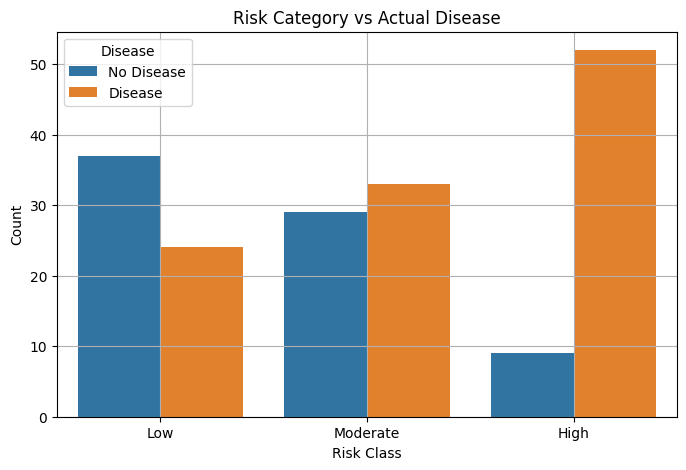

In [35]:
import seaborn as sns

print(pd.crosstab(test_df_fixed['risk_class'], test_df_fixed['target'],
                  rownames=['Risk Class'], colnames=['Actual Disease']))

plt.figure(figsize=(8, 5))
sns.countplot(data=test_df_fixed, x='risk_class', hue='target',
              order=['Low', 'Moderate', 'High'])
plt.title('Risk Category vs Actual Disease')
plt.xlabel('Risk Class')
plt.ylabel('Count')
plt.legend(title='Disease', labels=['No Disease', 'Disease'])
plt.grid(True)
plt.show()

## HRS Score Distribution Plot
This plot shows the distribution of Hybrid Risk Scores across patients.

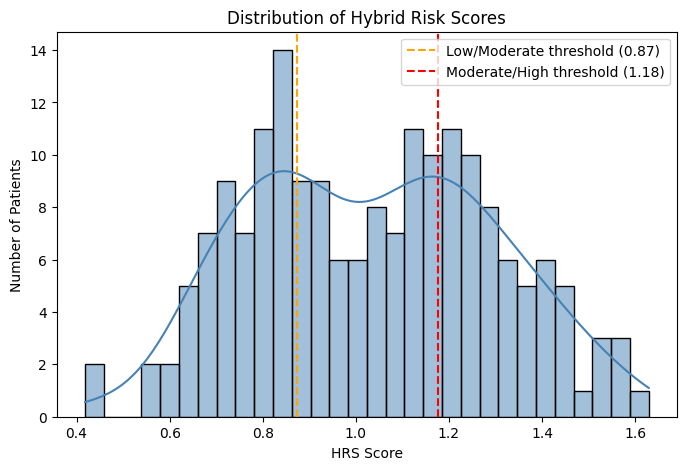

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(test_df_fixed["HRS_score"], bins=30, kde=True, color="steelblue")

plt.axvline(x=low_thresh, color="orange", linestyle="--", label=f"Low/Moderate threshold ({low_thresh:.2f})")
plt.axvline(x=high_thresh, color="red", linestyle="--", label=f"Moderate/High threshold ({high_thresh:.2f})")

plt.title("Distribution of Hybrid Risk Scores")
plt.xlabel("HRS Score")
plt.ylabel("Number of Patients")
plt.legend()

plt.savefig("hrs_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Loading trained CatBoost model
The trained CatBoost model is loaded to generate SHAP explainability plots.

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [ ]:
import shap

In [ ]:
import pickle

with open("/content/catboost_model.pkl", "rb") as f:
    cat_model = pickle.load(f)

explainer = shap.TreeExplainer(cat_model)

## SHAP-Based Explainability Analysis

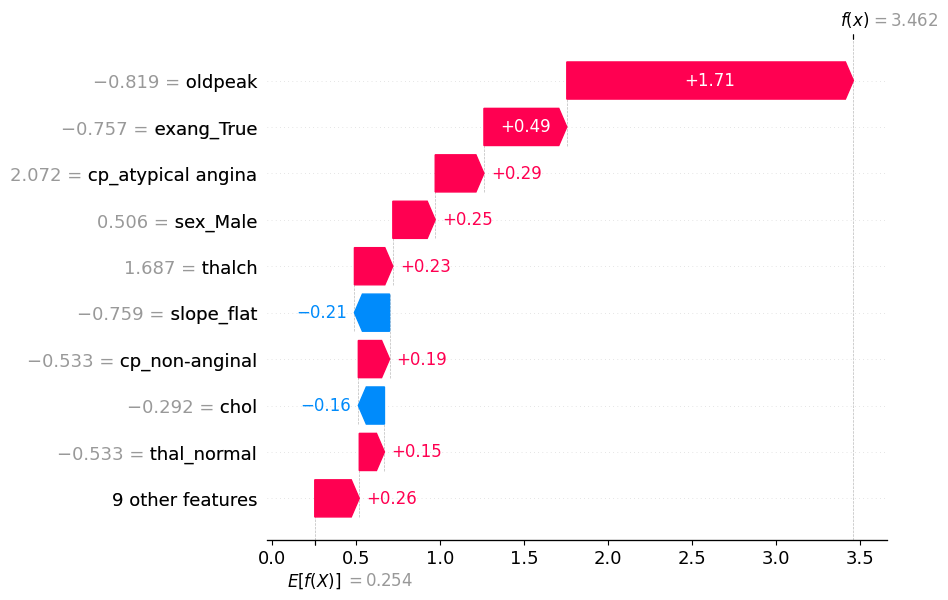

Waterfall plot saved for patient 1


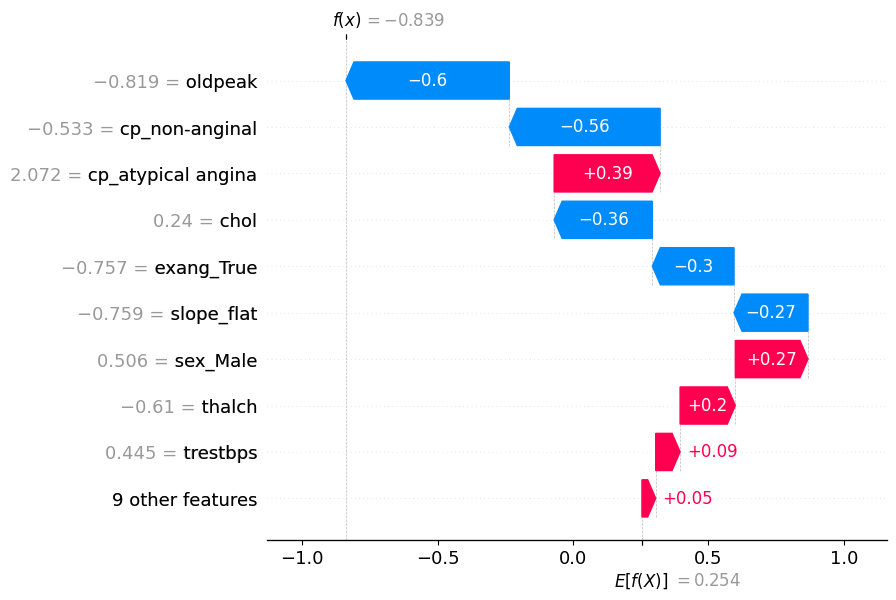

Waterfall plot saved for patient 2


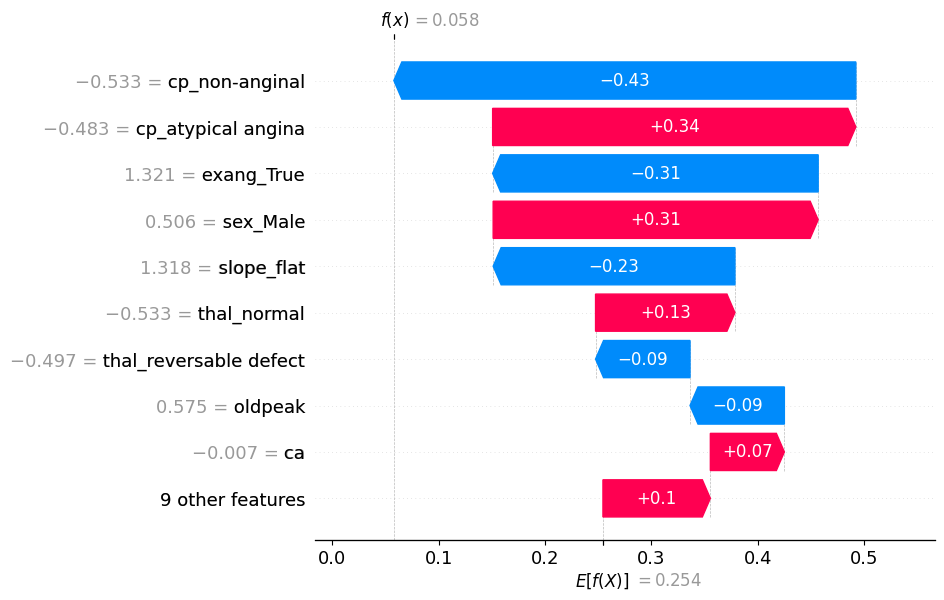

Waterfall plot saved for patient 3


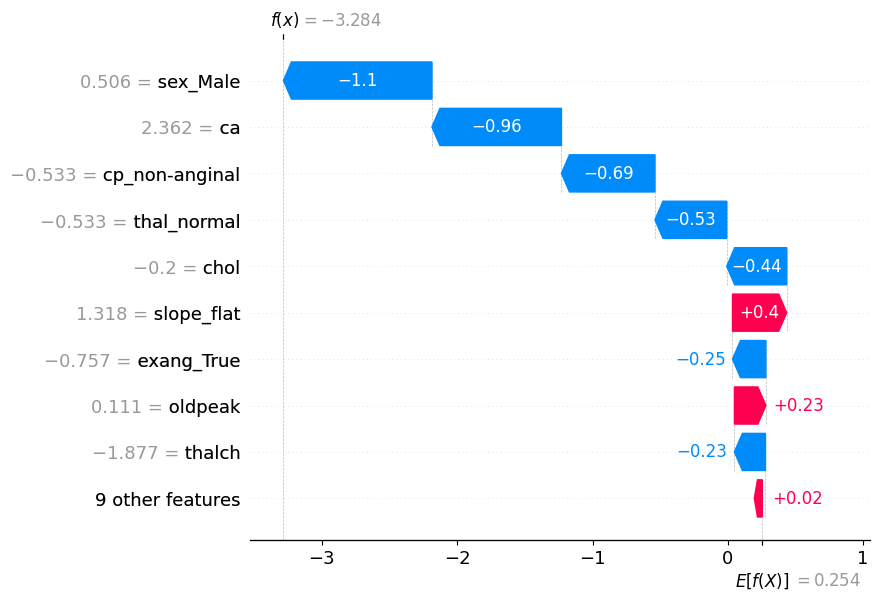

Waterfall plot saved for patient 4


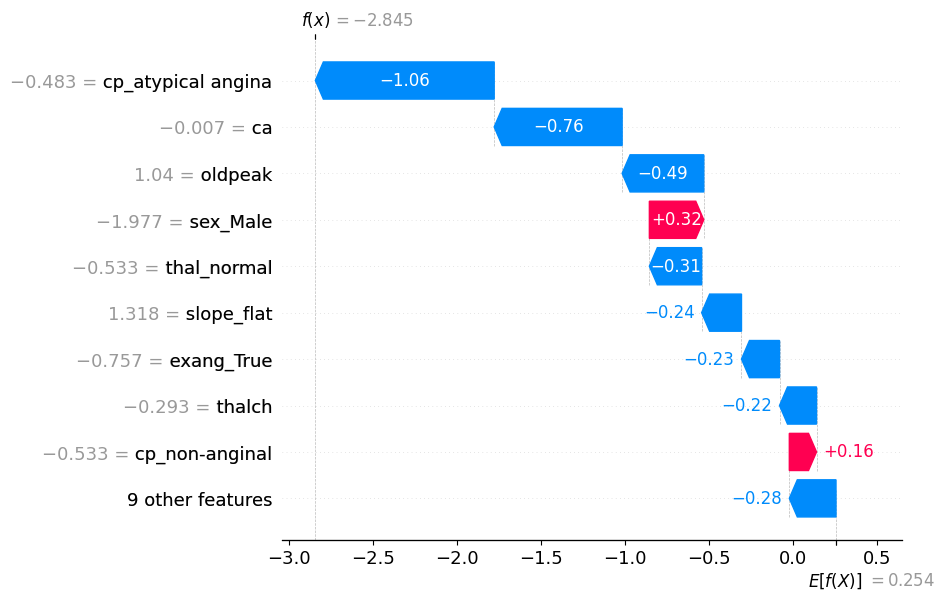

Waterfall plot saved for patient 5


In [ ]:
shap_values = np.load('/content/shap_values_cat.npy', allow_pickle=True)

import matplotlib.pyplot as plt

for i in range(5):
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[i],
            base_values=explainer.expected_value,
            data=X_test.iloc[i],
            feature_names=X_test.columns
        ),
        show=False
    )
    plt.savefig(f"waterfall_patient{i+1}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Waterfall plot saved for patient {i+1}")

<Figure size 2000x400 with 0 Axes>

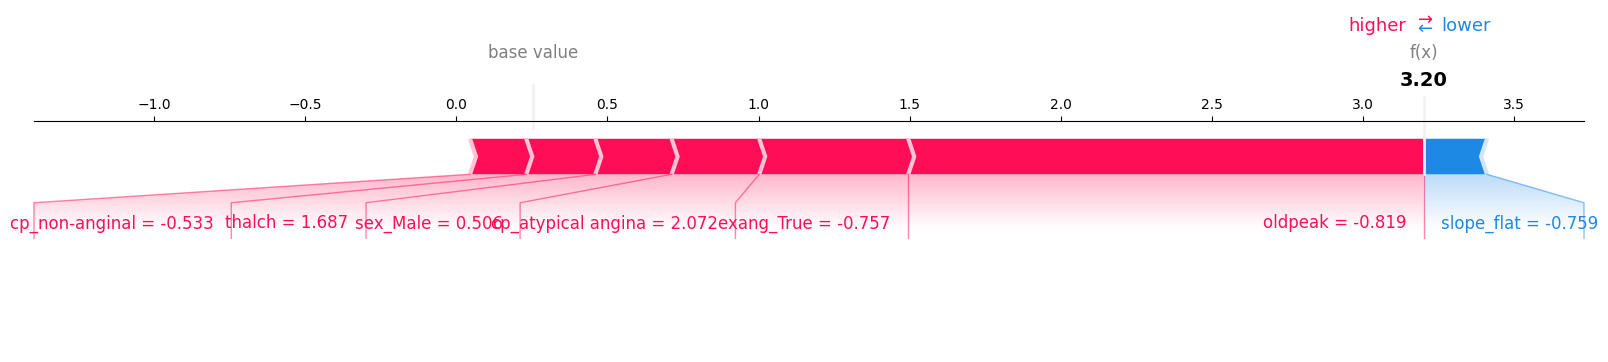

<Figure size 2000x400 with 0 Axes>

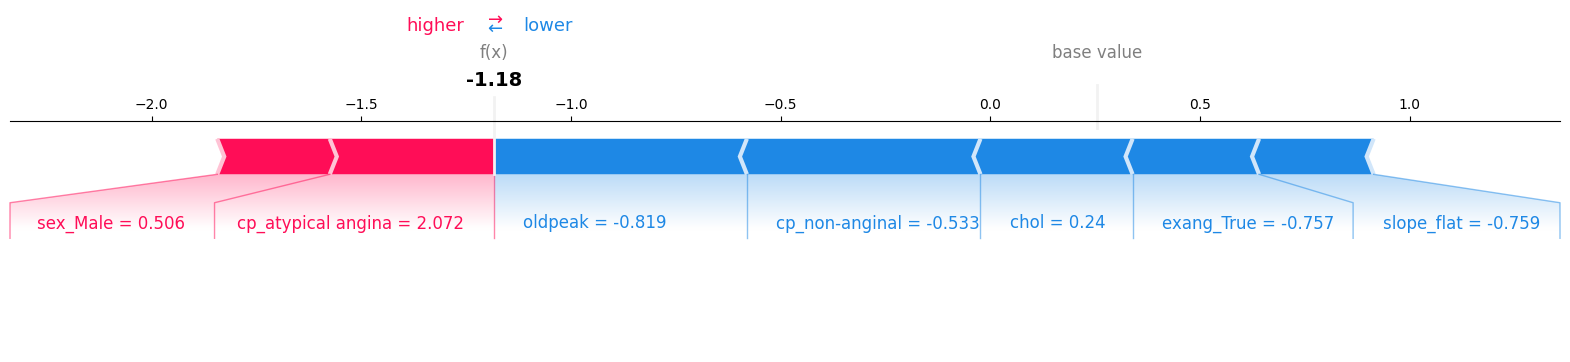

<Figure size 2000x400 with 0 Axes>

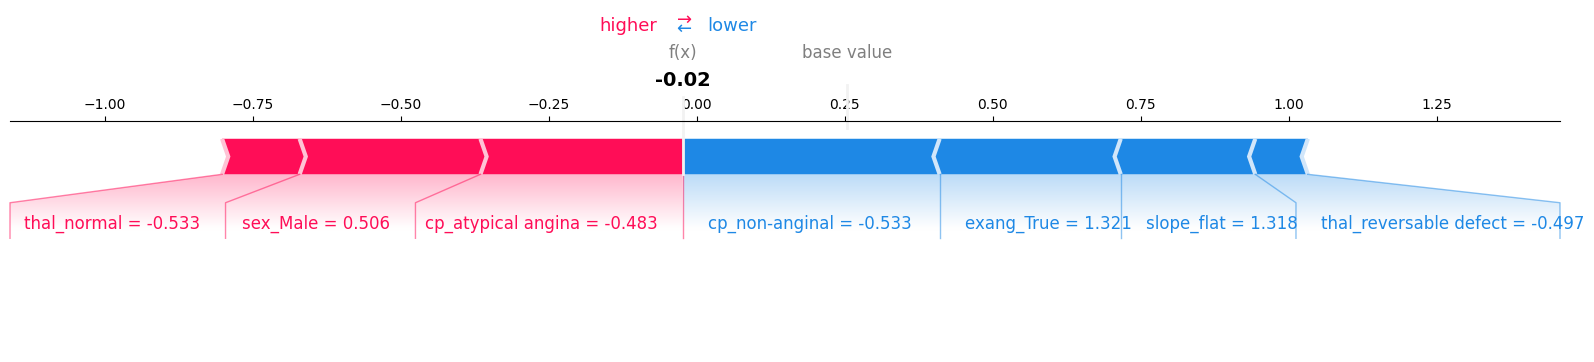

<Figure size 2000x400 with 0 Axes>

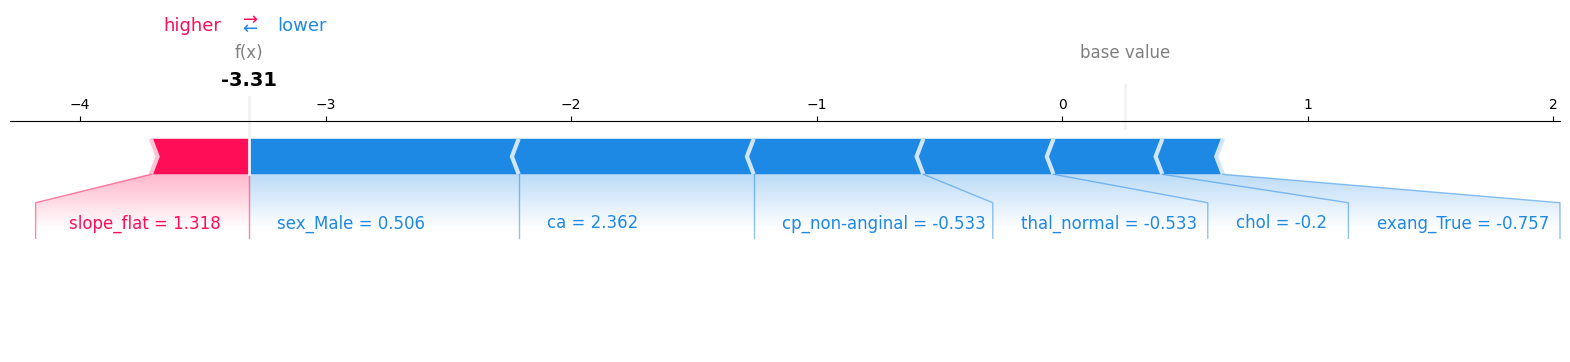

<Figure size 2000x400 with 0 Axes>

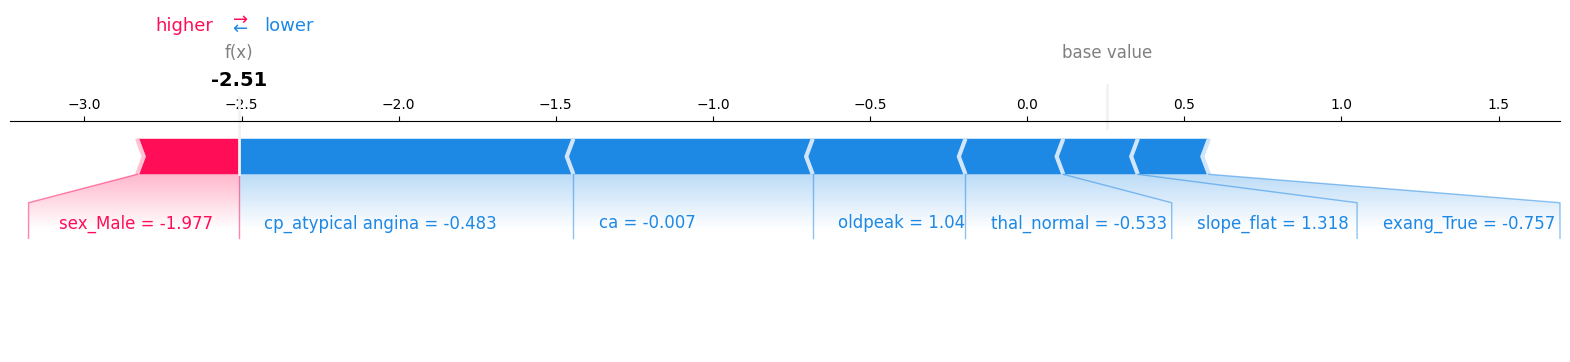

In [ ]:
for i in range(5):
    plt.figure(figsize=(20, 4))

    # Keep only top 10 features by SHAP magnitude
    sv = shap_values[i].copy()
    top_n = 7
    top_indices = np.argsort(np.abs(sv))[-top_n:]
    mask = np.zeros(len(sv))
    mask[top_indices] = 1
    sv = sv * mask

    shap.plots.force(
        explainer.expected_value,
        sv,
        X_test.iloc[i].round(3),
        feature_names=X_test.columns.tolist(),
        matplotlib=True,
        show=False
    )
    plt.savefig(f"force_patient{i+1}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()